# Loan Approval Prediction

## Introduction

This dataset describes loan applicants' characteristics and their risk assessment. It comprises information on various attributes of loan applicants, including demographic details, financial status, employment history, and ownership status. The dataset includes both numerical and categorical features, making it suitable for diverse analytical approaches. The dataset can be downloaded from Kaggle [here](https://www.kaggle.com/datasets/rohit265/loan-approval-dataset)

The columns dictionary is displayed as follows:

- Id: Unique identifier for each loan applicant.
- Income: The income level of the applicant.
- Age: Age of the applicant.
- Experience: Years of professional experience.
- Married/Single: Marital status of the applicant.
- House_Ownership: Indicates whether the applicant owns or rents a house.
- Car_Ownership: Indicates whether the applicant owns a car.
- Profession: Occupation or profession of the applicant.
- CITY: City of residence of the applicant.
- STATE: State of residence of the applicant.
- CURRENT_JOB_YRS: Duration of employment in the current job.
- CURRENT_HOUSE_YRS: Duration of residence in the current house.
- Risk_Flag: Binary indicator of loan risk, where 1 represents a flagged risky applicant and 0 represents a non-risky applicant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,make_scorer,recall_score

%matplotlib inline

In [2]:
df=pd.read_json('C:/Users/Public/Documents/yang/Data Science Project/data/loan_approval_dataset.json')

In [3]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 26.9+ MB


- There are no missing values.
- 'Risk_Flag' column will be the targe variable.

In [5]:
df.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [6]:
#checking the number of city
len(df['CITY'].unique())

317

In [7]:
#checking the number of state
len(df['STATE'].unique())

29

In [8]:
#checking the number of profession
len(df['Profession'].unique())

51

## EDA
Let's plot categorical data first

In [9]:
#Select categorical columns
cat_cols=list(df.select_dtypes(include=['object']).columns)

In [10]:
cat_cols

['Married/Single',
 'House_Ownership',
 'Car_Ownership',
 'Profession',
 'CITY',
 'STATE']

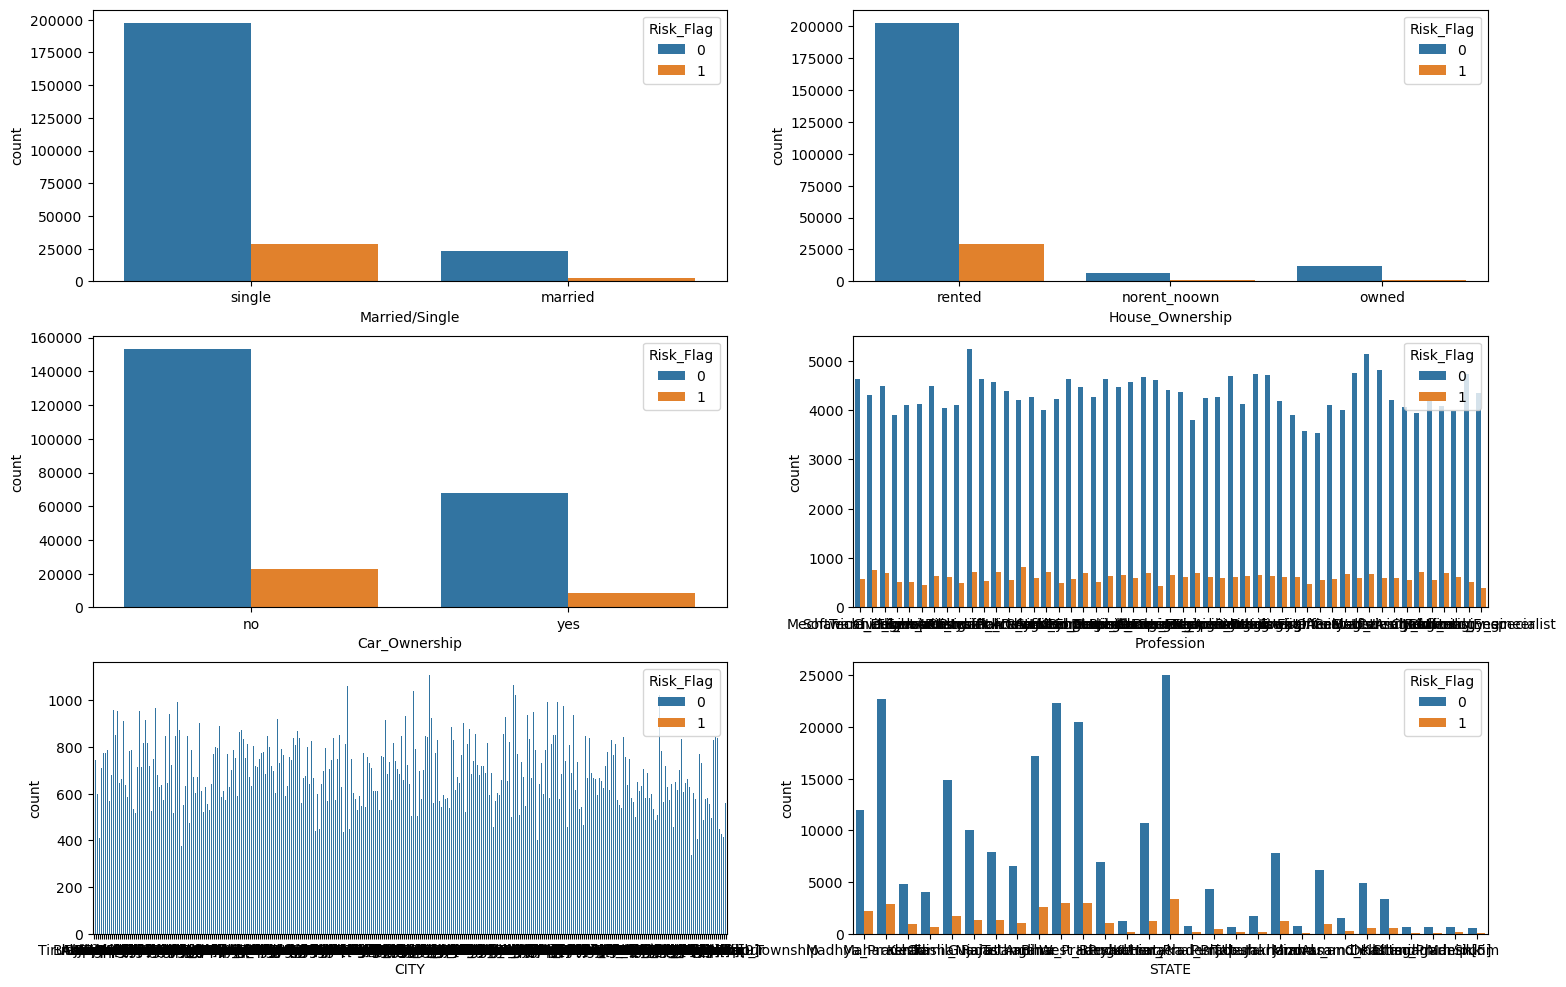

In [11]:
plt.figure(figsize=(18,12))
for idx, col in enumerate(cat_cols):
    ax=plt.subplot(3,2,idx+1)
    sns.countplot(x=df[col],hue=df['Risk_Flag'],ax=ax)
    
plt.show()

- According to the countplots, the target variable displays noticeable differences among car_onwership, marriage status, house ownership, and State while no major differences are observed among Profession and City.
- We will drop 'Profession' and 'City' columns for further analysis.

In [12]:
num_col=list(df.select_dtypes(include=['int64']).columns)

In [13]:
num_col.remove('Id')

In [14]:
num_col.remove('Risk_Flag')

In [15]:
num_col

['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']

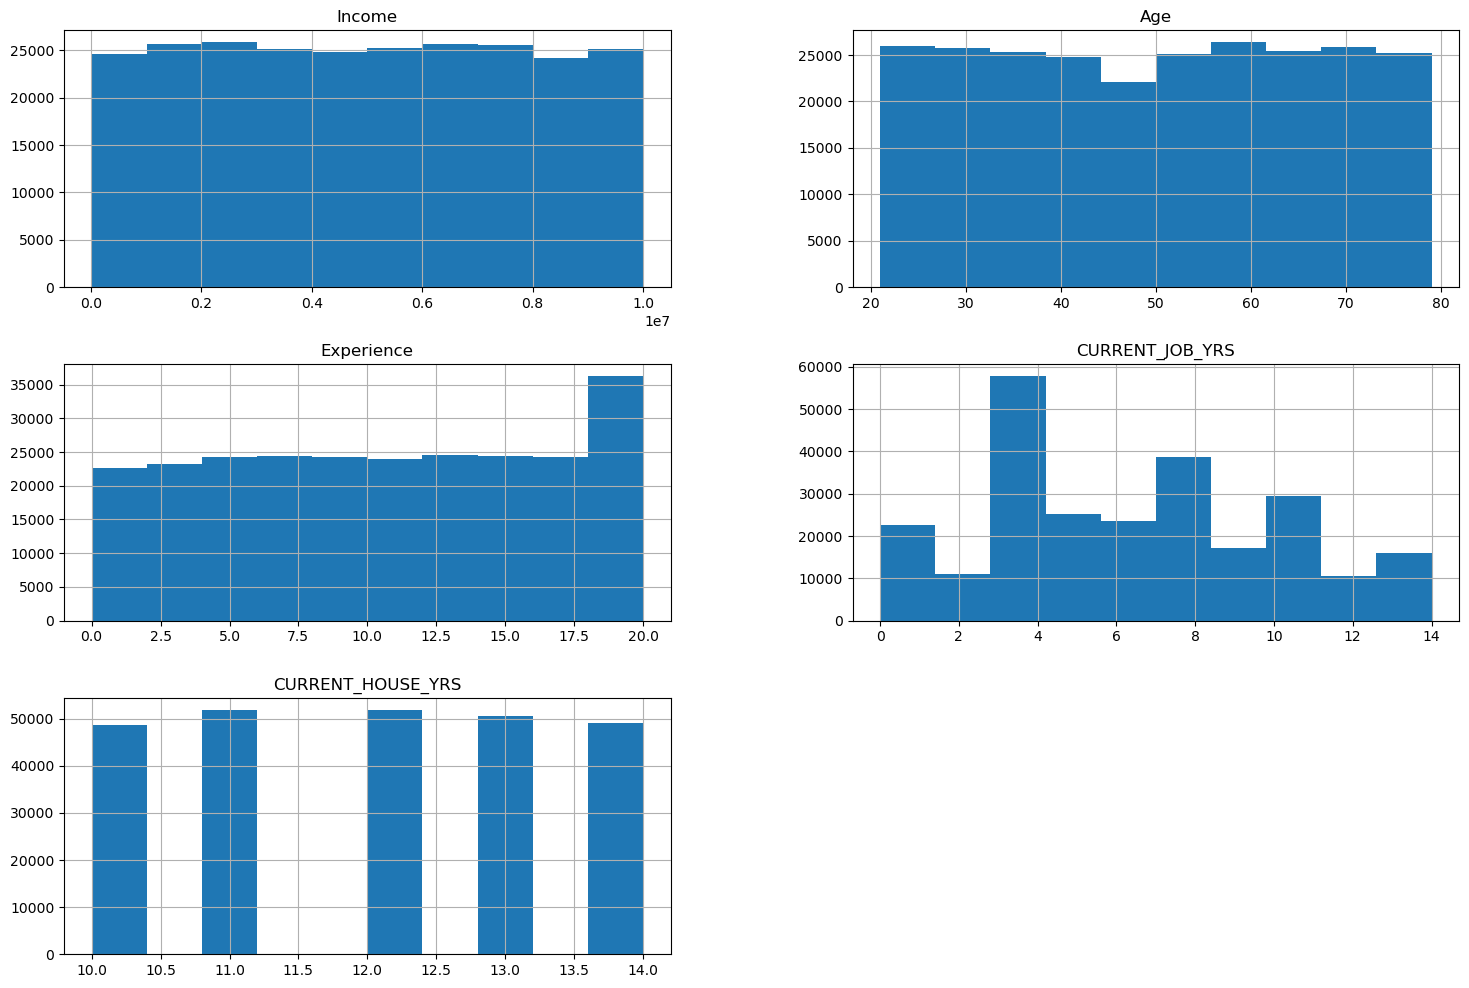

In [16]:
plt.figure(figsize=(18,12))
for idx, col in enumerate(num_col):
    ax=plt.subplot(3,2,idx+1)
    df.hist(col,ax=ax)
plt.show()

We don't observe any perculiar distributions for the numerical columns

In [17]:
#drop 'City','Profession', and 'Id' columns
df_c=df.drop(['CITY','Profession','Id'], axis=1)

In [18]:
df_c.columns=df_c.columns.str.lower()

In [19]:
df_fn=pd.get_dummies(df_c,dtype="int64")

In [20]:
df_fn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252000 entries, 0 to 251999
Data columns (total 42 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   income                        252000 non-null  int64
 1   age                           252000 non-null  int64
 2   experience                    252000 non-null  int64
 3   current_job_yrs               252000 non-null  int64
 4   current_house_yrs             252000 non-null  int64
 5   risk_flag                     252000 non-null  int64
 6   married/single_married        252000 non-null  int64
 7   married/single_single         252000 non-null  int64
 8   house_ownership_norent_noown  252000 non-null  int64
 9   house_ownership_owned         252000 non-null  int64
 10  house_ownership_rented        252000 non-null  int64
 11  car_ownership_no              252000 non-null  int64
 12  car_ownership_yes             252000 non-null  int64
 13  state_Andhra_Prades

In [21]:
cor=df_fn.corr()

In [22]:
cor['risk_flag']

income                         -0.003091
age                            -0.021809
experience                     -0.034523
current_job_yrs                -0.016942
current_house_yrs              -0.004375
risk_flag                       1.000000
married/single_married         -0.021092
married/single_single           0.021092
house_ownership_norent_noown   -0.012243
house_ownership_owned          -0.023499
house_ownership_rented          0.026647
car_ownership_no                0.024036
car_ownership_yes              -0.024036
state_Andhra_Pradesh           -0.007098
state_Assam                     0.004493
state_Bihar                     0.006741
state_Chandigarh               -0.004668
state_Chhattisgarh              0.003891
state_Delhi                    -0.008382
state_Gujarat                  -0.003498
state_Haryana                   0.000661
state_Himachal_Pradesh          0.001798
state_Jammu_and_Kashmir         0.009242
state_Jharkhand                 0.006021
state_Karnataka 

The state variables have very low correlations with the target variable. Let's drop all of them.

In [23]:
cols_to_drop=df_fn.filter(regex='^state').columns

In [24]:
df_fn1=df_fn.drop(cols_to_drop,axis=1)

In [25]:
df_fn1

,income,age,experience,current_job_yrs,current_house_yrs,risk_flag,married/single_married,married/single_single,house_ownership_norent_noown,house_ownership_owned,house_ownership_rented,car_ownership_no,car_ownership_yes
0,1303834,23,3,3,13,0,0,1,0,0,1,1,0
1,7574516,40,10,9,13,0,0,1,0,0,1,1,0
2,3991815,66,4,4,10,0,1,0,0,0,1,1,0
3,6256451,41,2,2,12,1,0,1,0,0,1,0,1
4,5768871,47,11,3,14,1,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
251995,8154883,43,13,6,11,0,0,1,0,0,1,1,0
251996,2843572,26,10,6,11,0,0,1,0,0,1,1,0
251997,4522448,46,7,7,12,0,0,1,0,0,1,1,0
251998,6507128,45,0,0,10,0,0,1,0,0,1,1,0


## Build the Model

In [26]:
X=df_fn1.drop('risk_flag',axis=1)
y=df_fn1['risk_flag']

#Starndardize X since the range of 'income' is much larger than other predicting variables
scaler=StandardScaler()
scaler.fit(X)
X_scaled=scaler.transform(X)

In [27]:
#Split the data: training(75%) and test(25%), setting random_state to 68 for reproducibility
X_train, X_test, y_train, y_test=train_test_split(X_scaled, y, test_size=0.25, random_state=68)

In [28]:
# checking whether both training and test datasets contain both cases(0 and 1)
print(f"training cases: {y_train.value_counts(normalize=True)}")
print(f"test cases: {y_test.value_counts(normalize=True)}")

training cases: risk_flag
0    0.876577
1    0.123423
Name: proportion, dtype: float64
test cases: risk_flag
0    0.87827
1    0.12173
Name: proportion, dtype: float64


It looks good. Let's move on

In [29]:
# since the ratio of non-case and case is almost 9:1, we applied the 'balanced' class_weight for the model
model=LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced')

## Model Evaluation

In [30]:
#accuracy of training dataset
accuracy_train=model.score(X_train,y_train)

In [31]:
accuracy_train

0.5003650793650793

In [32]:
y_pred_train=model.predict(X_train)

In [33]:
#calculate confusion matrix
cm=confusion_matrix(y_train, y_pred_train)

In [34]:
cm

array([[80994, 84679],
       [ 9752, 13575]], dtype=int64)

In [35]:
#true positivity
tp=cm[1,1]

In [36]:
#true negativity
tn=cm[0,0]

In [37]:
#false positivity
fp=cm[0,1]

In [38]:
#false negativity
fn=cm[1,0]

In [39]:
sensitivity_train=tp/(tp+fn)

In [40]:
sensitivity_train

0.5819436704248296

In [41]:
specificity_train=tn/(tn+fp)

In [42]:
specificity_train

0.488878694778268

- The training model's accuracy is about 50%. 
- The model's sensitivity is  58.19%( The model's accuracy for predicting cases is  58.19%)
- The specificity is 48.89%
- The model performance is slightly better at predicting the cases(risk cases) for loan approval

Let's examine the model performance on test set

In [43]:
accuracy_test=model.score(X_test, y_test)

In [44]:
accuracy_test

0.5015396825396825

In [45]:
y_pred_test=model.predict(X_test)

In [46]:
#Calculate the confusion matrix
cm_test=confusion_matrix(y_test,y_pred_test)

In [47]:
cm_test

array([[27179, 28152],
       [ 3251,  4418]], dtype=int64)

In [48]:
tn_test=cm_test[0,0]

In [49]:
fn_test=cm_test[1,0]

In [50]:
fp_test=cm_test[0,1]
tp_test=cm_test[1,1]

In [51]:
sensitivity_test=tp_test/(fn_test+tp_test)

In [52]:
sensitivity_test

0.5760855391837267

In [53]:
specificity_test=tn_test/(tn_test+fp_test)

In [54]:
specificity_test

0.4912074605555656

- The test set has an accuracy of 50.15%
- The test's sensitivity is 57.61%
- The test's specificity is 49.12%
- According to the test set, the model is better at predicting cases(risk cases for load approval)
- The performance of test set is consistent with the training set.


## Interpreting the Model Coefficients

In [55]:
#intercept

intercept=model.intercept_

In [56]:
intercept

array([-0.01354803])

In [57]:
#Calculate the odds
odds=np.exp(intercept)

In [58]:
odds

array([0.98654333])

When the predictor is 0, the person is more likely to be non-risk

In [59]:
coef=model.coef_

In [60]:
coef

array([[-0.01299281, -0.06219099, -0.13606341,  0.04565155, -0.0090952 ,
        -0.0350881 ,  0.0350881 , -0.01755638, -0.04726573,  0.04925616,
         0.03535868, -0.03535868]])

In [61]:
X.columns

Index(['income', 'age', 'experience', 'current_job_yrs', 'current_house_yrs',
       'married/single_married', 'married/single_single',
       'house_ownership_norent_noown', 'house_ownership_owned',
       'house_ownership_rented', 'car_ownership_no', 'car_ownership_yes'],
      dtype='object')

Let's only interpret the coefficients of first four predictors as examples: ''income', 'age', 'experience', and 'current_job_yrs'.

In [62]:
np.exp(coef[0,:4])

array([0.98709124, 0.9397034 , 0.87278729, 1.04670962])

In [63]:
for col,lg_o in zip(X.columns[:4],coef[0,:4]):
    print(f'The log odds of {col}: {lg_o}')

The log odds of income: -0.012992805766327734
The log odds of age: -0.06219099009938374
The log odds of experience: -0.13606341146790796
The log odds of current_job_yrs: 0.04565154621163904


In [64]:
for col, lg_o in zip(X.columns[:4],coef[0,:4]):
    print(f'The odds ratio of {col}: {round(np.exp(lg_o),2)}')

The odds ratio of income: 0.99
The odds ratio of age: 0.94
The odds ratio of experience: 0.87
The odds ratio of current_job_yrs: 1.05


- Higher 'income', 'age' and 'experience' are associated with lower odds of "being risk" for loan approval. One unit change in income, age, and experience result in a decrease in "risk" by 1%, 6%, and 13% respectively.
- Higher 'curren_job_yrs' is associated with higher odds of 'risk' for loan approval. One unit change in 'current_job_yrs' results in a increase of 'risk' by 5%.

## Cross Validation

In [65]:
#perform 5 folds cross validation with 'accuracy' score
accuracies_cv=cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

In [66]:
accuracies_cv

array([0.50446429, 0.51732143, 0.49363095, 0.51996032, 0.49113095])

In [67]:
accuracies_cv.mean()

0.5053015873015874

Let's also perform cross validation with sensitivity score

In [68]:
sensitivity=make_scorer(recall_score)

In [69]:
sty_cv=cross_val_score(model,X_scaled, y, cv=5, scoring=sensitivity)

In [70]:
sty_cv

array([0.56299403, 0.54541055, 0.62929505, 0.52976286, 0.51435484])

In [71]:
sty_cv.mean()

0.5563634665320629

- The average accuracy score from 5 folds cross validation is 50.53%
- The average sensitivity score from 5 folds cross validation is 55.64%
- The cross validation is consistent with the training and test performance.

## Summary

- In this project, we used the logistics regression to predict the risk for loan approval. The average model accuracy is 50.53%. The model performance is not good enough, due to the fact that the predictors have low correlations with the target variable. The model is slightly better at predicting the 'risk' cases for loan approval. The decision tree or random forest might imporve the model performance for the future exploration.